### Imports 

In [1]:
from sklearn.preprocessing import StandardScaler, PowerTransformer
from sklearn.pipeline import Pipeline 
from sklearn.linear_model import Ridge 
from sklearn.model_selection import GridSearchCV, KFold
import pandas as pd
import os 
import numpy as np
import statsmodels.api as sm
from sklearn.compose import ColumnTransformer
from sklearn.metrics import mean_absolute_error

In [2]:
os.chdir("../")  

In [3]:
from src.land_value_prediction.feature_selection import plot_strong_correlations

c:\Users\leoco\Documents\cours\M2_MOSEF\ML_theory\land_value_prediction\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
train_df = pd.read_parquet("data/processed/selected_features/idf_vf_train_selected_features.parquet")
test_df  = pd.read_parquet("data/processed/selected_features/idf_vf_test_selected_features.parquet")
oos_df = pd.read_parquet("data/processed/selected_features/idf_vf_out_of_sample_selected_features.parquet")

In [5]:
train_df = train_df.drop(columns="code_departement")
test_df = test_df.drop(columns="code_departement")
oos_df = oos_df.drop(columns="code_departement")

In [6]:
X_train = train_df.drop(columns=["prix_m2"])
y_train = train_df["prix_m2"]

X_test = test_df.drop(columns=["prix_m2"])
y_test = test_df["prix_m2"]

X_oos = oos_df.drop(columns=["prix_m2"])
y_oos = oos_df["prix_m2"]

In [7]:
X_train.columns

Index(['prix_m2_median_maisons_voisines', 'ratio_terrain_bati',
       'surface_x_type', 'commune_education_score_2013_commune',
       'densite_rel_2000m', 'is_appartement', 'nombre_lots',
       'nb_transport_autre_2000m', 'commune_part_commerce_tourisme',
       'commune_densite_residences_principales_2020', 'distance_paris',
       'nombre_pieces_principales', 'commune_revenu_median_2020',
       'commune_etablissements_1_salarie_2021', 'surface_par_piece',
       'commune_ratio_residences_secondaires_population', 'nb_loisirs_2000m',
       'Taux_moyen_credit_immo_lag1t', 'commune_taux_proprietaires',
       'dist_transport_lourd', 'Evolution_PIB_volume_en_%_base2020_lag4t',
       'nb_services_2000m'],
      dtype='object')

### 1. Suppression des variables trop corrélées pour ridge 

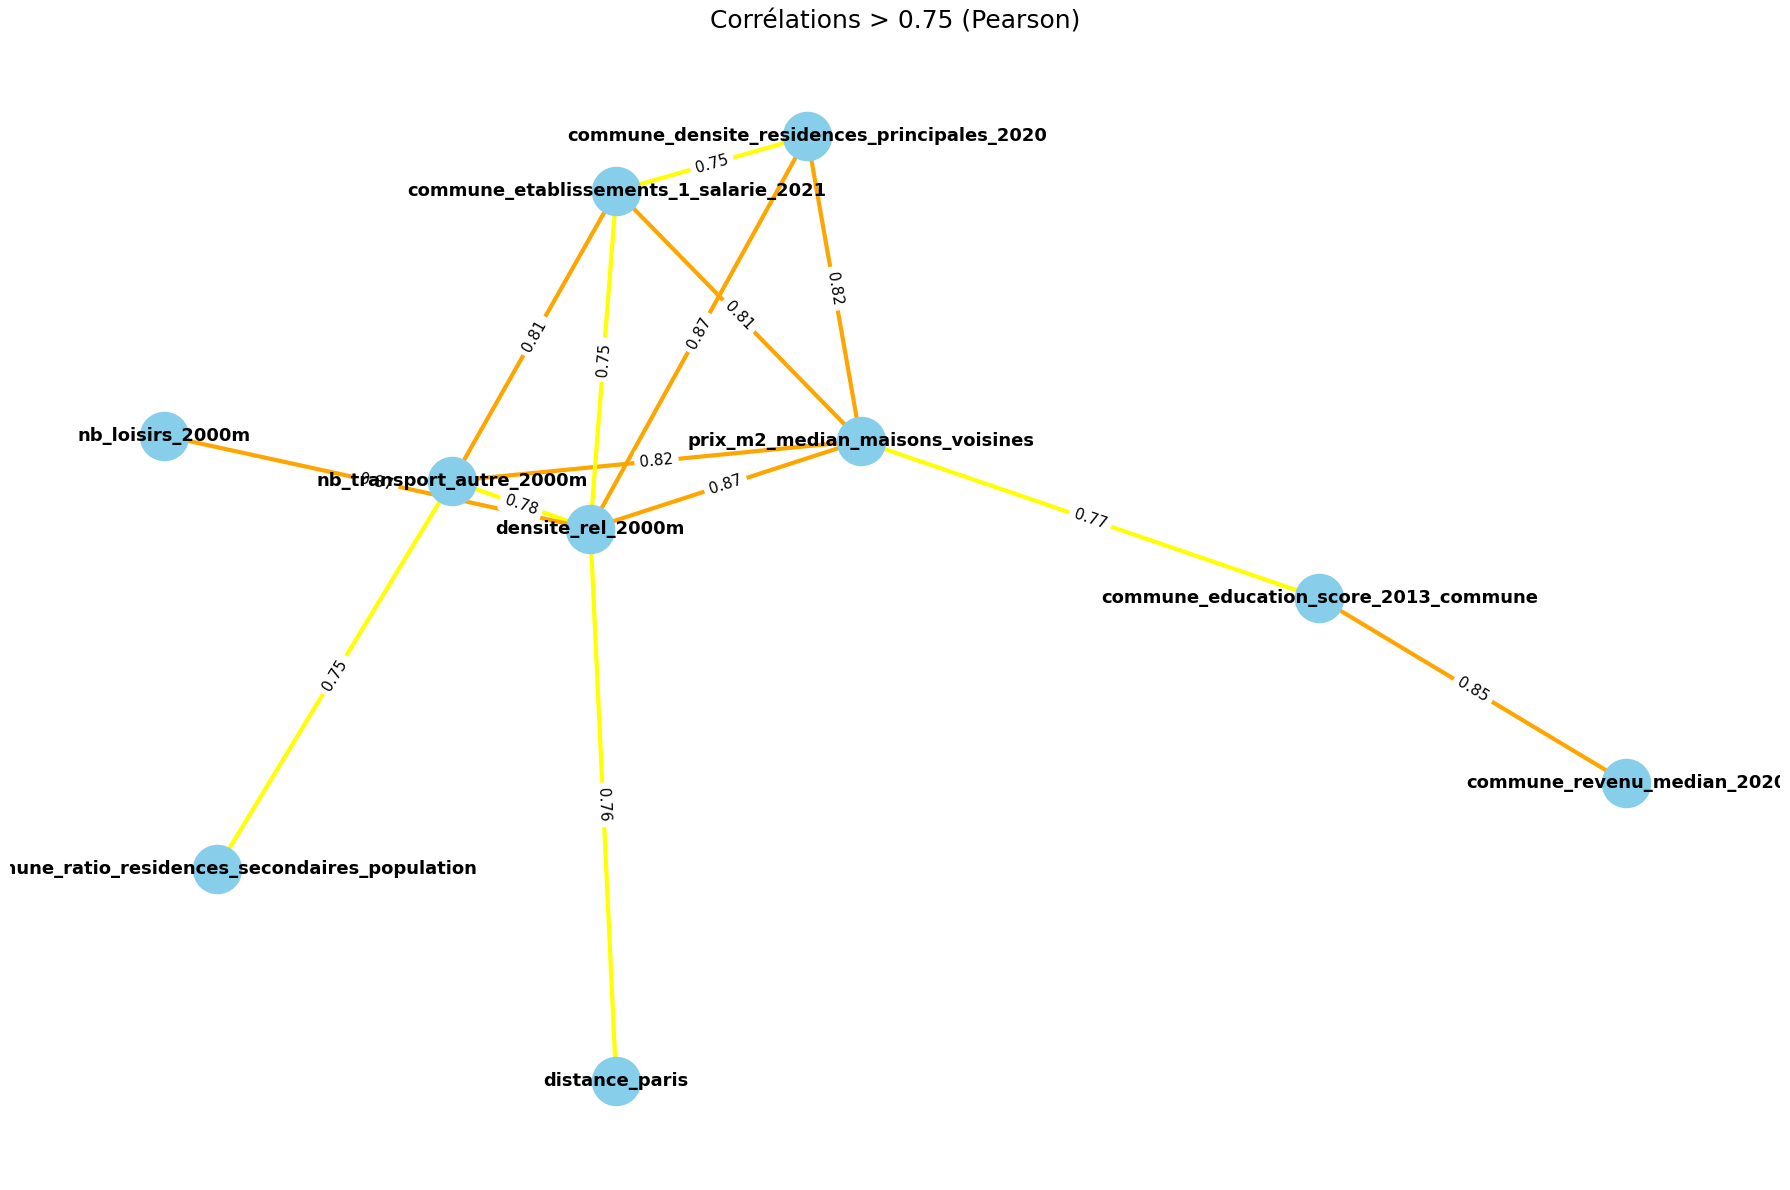

In [8]:
plot_strong_correlations(X_train, threshold=0.75)

On va tester deux cas :
- options 1 : enlever le prix median des maisons voisines et garder les POI (ceux non corrélés)
- option 2 : garder le prix median des maisons voisines et enlever les POI 

#### Option 1

In [9]:
features_to_drop_1 = [
    "prix_m2_median_maisons_voisines",
    "commune_revenu_median_2020",
    "densite_rel_2000m",
    "commune_etablissements_1_salarie_2021"
]

selected_features_1 = X_train.drop(columns=features_to_drop_1).columns.tolist()

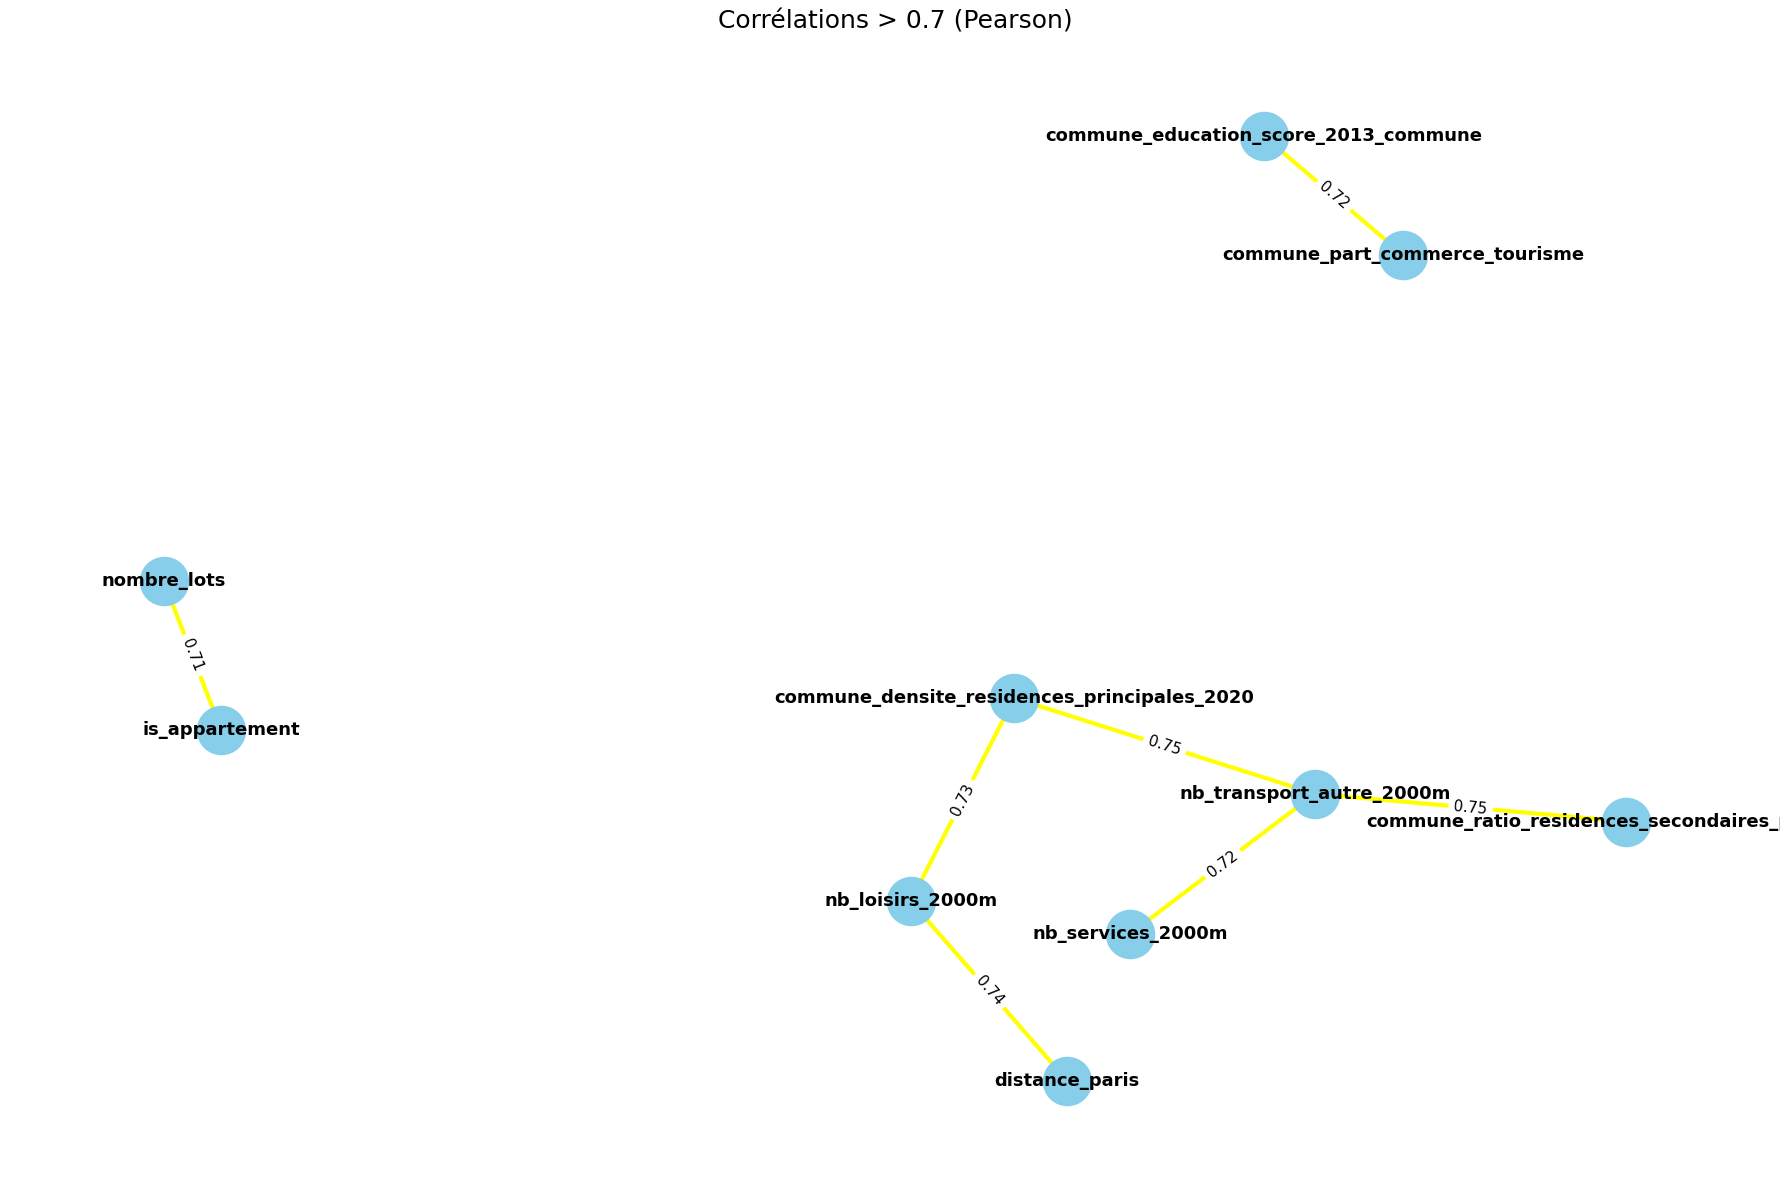

In [10]:
plot_strong_correlations(X_train[selected_features_1], threshold=0.7)

In [11]:
X_train[selected_features_1]

,ratio_terrain_bati,surface_x_type,commune_education_score_2013_commune,is_appartement,nombre_lots,nb_transport_autre_2000m,commune_part_commerce_tourisme,commune_densite_residences_principales_2020,distance_paris,nombre_pieces_principales,surface_par_piece,commune_ratio_residences_secondaires_population,nb_loisirs_2000m,Taux_moyen_credit_immo_lag1t,commune_taux_proprietaires,dist_transport_lourd,Evolution_PIB_volume_en_%_base2020_lag4t,nb_services_2000m
0,0.000000,96,0.824937,1,1,29,0.852084,15346.884766,0.022898,3,16.0,0.093602,311,0.0120,0.370956,144.457687,-5.068832,14
1,0.000000,90,0.471073,1,2,0,0.695597,4164.813965,0.067297,3,15.0,0.010882,332,0.0113,0.243751,600.407043,-12.214629,8
2,0.000000,102,0.998930,1,2,43,0.862807,12465.445312,0.012333,2,25.5,0.146887,270,0.0140,0.345093,152.974091,2.991206,18
3,0.000000,240,0.960340,1,1,49,0.894205,10157.753906,0.010092,3,40.0,0.211263,252,0.0120,0.316352,118.246140,-5.068832,17
4,2.227273,88,0.455148,0,0,1,0.657143,461.768066,0.337793,5,17.6,0.004247,41,0.0178,0.557275,1995.224365,0.559991,7
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
469169,0.000000,140,0.558072,1,2,1,0.714286,1754.606445,0.586708,4,17.5,0.030661,53,0.0140,0.523755,2903.486328,2.991206,1
469170,4.601942,103,0.443735,0,0,1,0.741100,208.464325,0.445244,5,20.6,0.003642,33,0.0106,0.465197,597.018799,15.361810,0
469171,7.727273,110,0.377666,0,0,0,0.500000,26.528963,0.827513,4,27.5,0.083745,3,0.0112,0.666281,13838.716797,1.215887,2
469172,2.870588,85,0.355047,0,0,1,0.744986,558.810059,0.512374,5,17.0,0.005702,51,0.0113,0.475808,1396.384399,-12.214629,5


#### Option 2 

In [12]:
features_to_drop_2 = [
    "commune_education_score_2013_commune",
    "densite_rel_2000m",
    "commune_etablissements_1_salarie_2021", 
    'nb_transport_autre_2000m',
    'commune_densite_residences_principales_2020']

selected_features_2 = X_train.drop(columns=features_to_drop_2).columns.tolist()

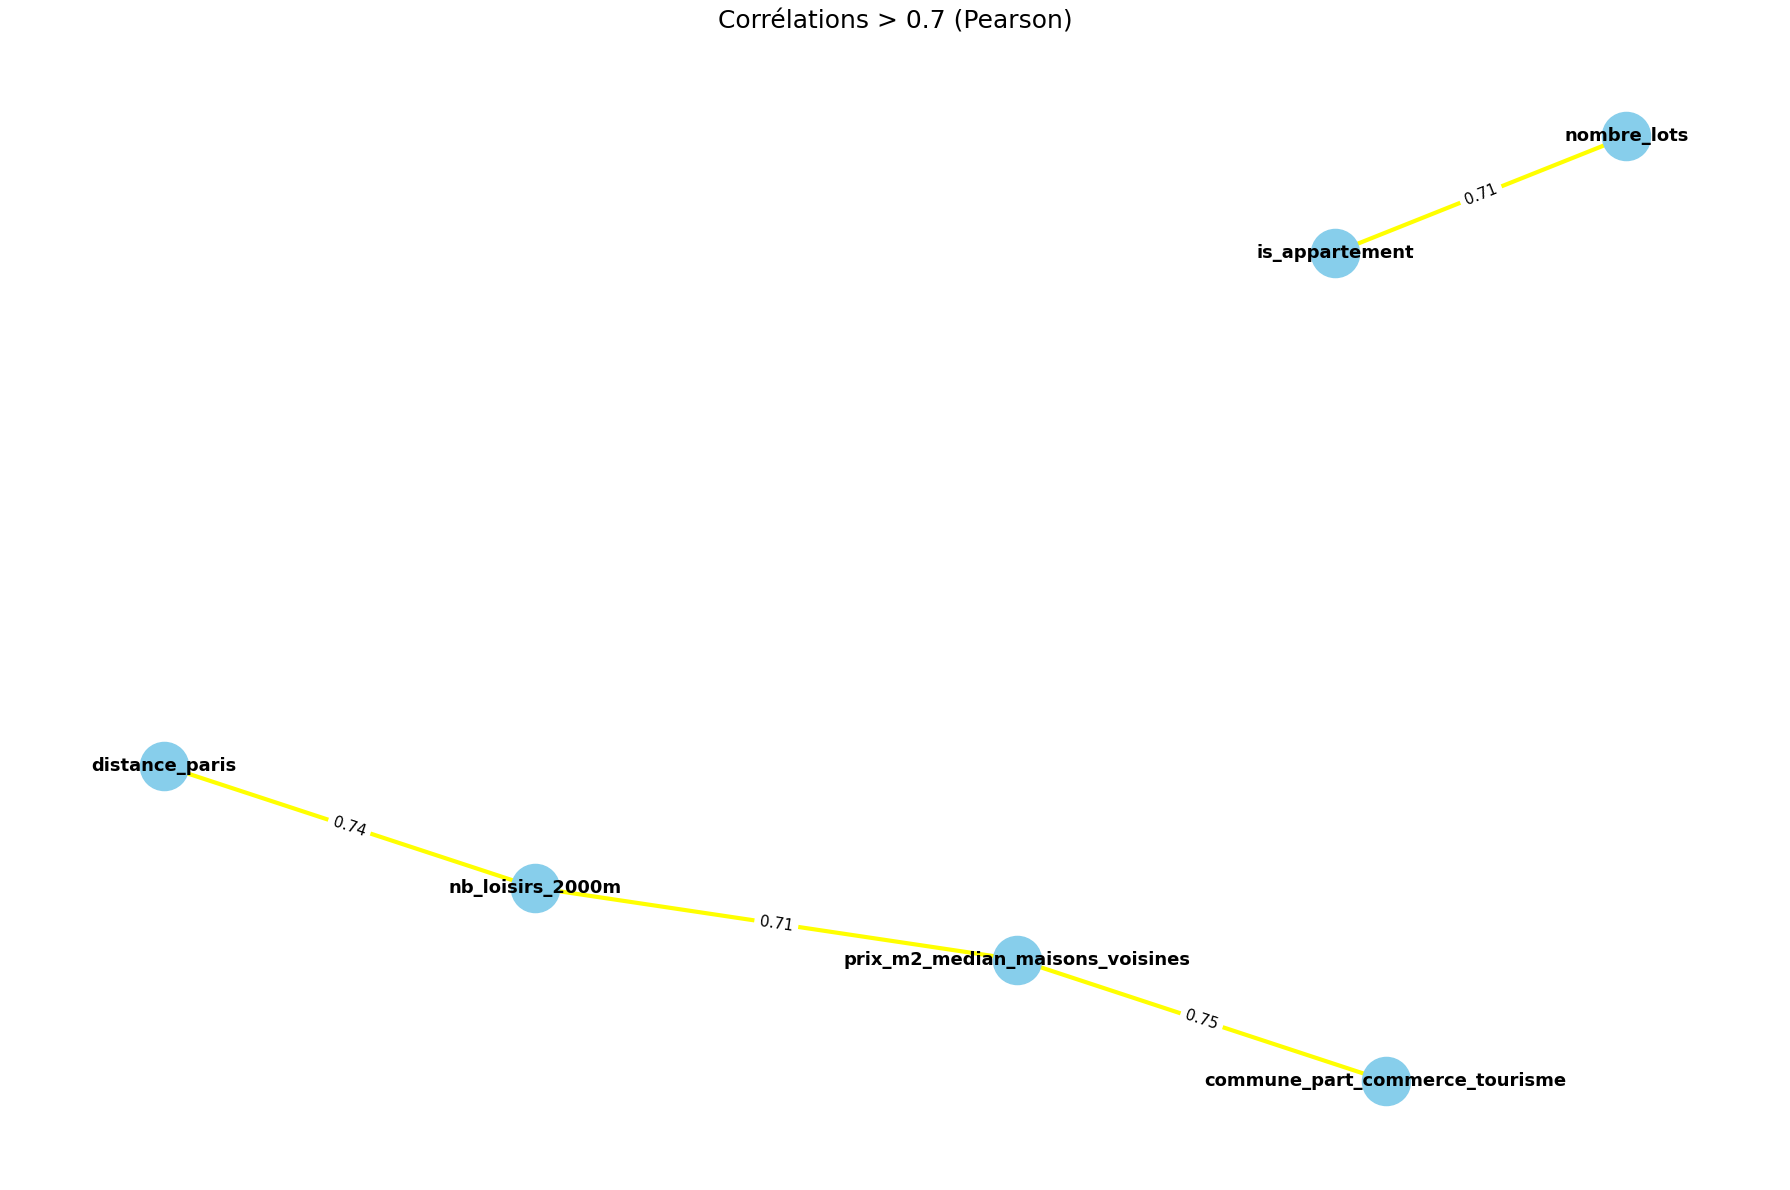

In [13]:
plot_strong_correlations(X_train[selected_features_2], threshold=0.7)

In [14]:
X_train[selected_features_2]

,prix_m2_median_maisons_voisines,ratio_terrain_bati,surface_x_type,is_appartement,nombre_lots,commune_part_commerce_tourisme,distance_paris,nombre_pieces_principales,commune_revenu_median_2020,surface_par_piece,commune_ratio_residences_secondaires_population,nb_loisirs_2000m,Taux_moyen_credit_immo_lag1t,commune_taux_proprietaires,dist_transport_lourd,Evolution_PIB_volume_en_%_base2020_lag4t,nb_services_2000m
0,11000.000000,0.000000,96,1,1,0.852084,0.022898,3,28060.0,16.0,0.093602,311,0.0120,0.370956,144.457687,-5.068832,14
1,5948.511230,0.000000,90,1,2,0.695597,0.067297,3,20490.0,15.0,0.010882,332,0.0113,0.243751,600.407043,-12.214629,8
2,12951.613281,0.000000,102,1,2,0.862807,0.012333,2,34650.0,25.5,0.146887,270,0.0140,0.345093,152.974091,2.991206,18
3,12958.437500,0.000000,240,1,1,0.894205,0.010092,3,31790.0,40.0,0.211263,252,0.0120,0.316352,118.246140,-5.068832,17
4,3145.161377,2.227273,88,0,0,0.657143,0.337793,5,22210.0,17.6,0.004247,41,0.0178,0.557275,1995.224365,0.559991,7
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
469169,2194.827637,0.000000,140,1,2,0.714286,0.586708,4,23840.0,17.5,0.030661,53,0.0140,0.523755,2903.486328,2.991206,1
469170,3378.333252,4.601942,103,0,0,0.741100,0.445244,5,23750.0,20.6,0.003642,33,0.0106,0.465197,597.018799,15.361810,0
469171,1954.318970,7.727273,110,0,0,0.500000,0.827513,4,22450.0,27.5,0.083745,3,0.0112,0.666281,13838.716797,1.215887,2
469172,3367.519775,2.870588,85,0,0,0.744986,0.512374,5,22380.0,17.0,0.005702,51,0.0113,0.475808,1396.384399,-12.214629,5


### 2. Traitements et modélisation

In [ ]:
param_grid = {
    'preprocessor__scaler': [StandardScaler(), PowerTransformer(method="yeo-johnson")],
    'ridge__alpha': np.logspace(-3, 1, 20)  # Explore a wider range, from 0.001 to 10. 
}

cols_to_scale_1 = [col for col in selected_features_1 if col != 'log_surface_bati']

pipe_1 = Pipeline([
    ("preprocessor", ColumnTransformer([
        ("scaler", StandardScaler(), cols_to_scale_1)
    ], remainder='passthrough')),
    ("ridge", Ridge(random_state=42))
])

cv = KFold(n_splits=5, shuffle=True, random_state=42)
grid = GridSearchCV(pipe_1, param_grid, cv=cv, scoring="neg_mean_absolute_error", n_jobs=-1)
grid.fit(X_train[selected_features_1], y_train)

print("Meilleur score MAE CV :", -grid.best_score_)
print("Meilleure normalisation :", type(grid.best_params_['preprocessor__scaler']).__name__)
print("Meilleur alpha :", grid.best_params_['ridge__alpha'])

Meilleur score MAE CV : 1326.1956496080604
Meilleure normalisation : StandardScaler
Meilleur alpha : 0.001


In [16]:
cols_to_scale_2 = [col for col in selected_features_2 if col != 'log_surface_bati']

pipe_2 = Pipeline([
    ("preprocessor", ColumnTransformer([
        ("scaler", StandardScaler(), cols_to_scale_2)
    ], remainder='passthrough')),
    ("ridge", Ridge(random_state=42))
])

cv = KFold(n_splits=5, shuffle=True, random_state=42)
grid = GridSearchCV(pipe_2, param_grid, cv=cv, scoring="neg_mean_absolute_error", n_jobs=-1)
grid.fit(X_train[selected_features_2], y_train)

print("Meilleur score MAE CV :", -grid.best_score_)
print("Meilleure normalisation :", type(grid.best_params_['preprocessor__scaler']).__name__)
print("Meilleur alpha :", grid.best_params_['ridge__alpha'])

Meilleur score MAE CV : 1172.267560518692
Meilleure normalisation : StandardScaler
Meilleur alpha : 0.001


Pas besoin de pénalisation à priori 

### 3. Interprétabilité 

In [17]:
# Option 1
best_scaler_1 = grid.best_params_['preprocessor__scaler']
best_alpha_1 = grid.best_params_['ridge__alpha']

model_1 = Pipeline([
    ("scaler", best_scaler_1),
    ("ridge", Ridge(alpha=best_alpha_1, random_state=42))
])
model_1.fit(X_train[selected_features_1], y_train)

y_train_pred_1 = model_1.predict(X_train[selected_features_1])
y_test_pred_1 = model_1.predict(X_test[selected_features_1])

mae_train_1 = mean_absolute_error(y_train, y_train_pred_1)
mae_test_1 = mean_absolute_error(y_test, y_test_pred_1)

print("Option 1 - MAE train:", mae_train_1)
print("Option 1 - MAE test:", mae_test_1)

coeffs_1 = model_1.named_steps['ridge'].coef_
coef_df_1 = pd.DataFrame({'feature': selected_features_1, 'coefficient': coeffs_1})

# Calcul des p-values pour les coefficients du modèle Ridge (approximation via OLS)
X_train_sm = sm.add_constant(X_train[selected_features_1])
ols_model = sm.OLS(y_train, X_train_sm).fit()
pvalues = ols_model.pvalues.drop('const')

coef_df_1['pvalue'] = coef_df_1['feature'].map(pvalues)
coef_df_1.sort_values('coefficient', key=abs, ascending=False)

Option 1 - MAE train: 1326.0803115119736
Option 1 - MAE test: 1320.480232728697


,feature,coefficient,pvalue
2,commune_education_score_2013_commune,910.031682,0.000000e+00
9,nombre_pieces_principales,-757.336836,0.000000e+00
7,commune_densite_residences_principales_2020,525.165829,0.000000e+00
3,is_appartement,-523.084459,0.000000e+00
5,nb_transport_autre_2000m,488.471128,0.000000e+00
12,nb_loisirs_2000m,430.778436,0.000000e+00
1,surface_x_type,346.696458,0.000000e+00
4,nombre_lots,-304.952743,0.000000e+00
10,surface_par_piece,-301.588683,0.000000e+00
17,nb_services_2000m,284.554325,0.000000e+00


In [18]:
# Pour retrouver les coefficients dans l'échelle d'origine des variables
scaler_1 = model_1.named_steps['scaler']
ridge_1 = model_1.named_steps['ridge']

coef_orig_1 = ridge_1.coef_ / scaler_1.scale_
intercept_orig_1 = ridge_1.intercept_ - np.sum(ridge_1.coef_ * scaler_1.mean_ / scaler_1.scale_)

coef_df_orig_1 = pd.DataFrame({'feature': selected_features_1, 'coefficient_orig': coef_orig_1})
coef_df_orig_1.sort_values('coefficient_orig', key=abs, ascending=False)

print('Intercept (échelle originale) :', intercept_orig_1)
coef_df_orig_1

Intercept (échelle originale) : 4854.2176052694485


,feature,coefficient_orig
0,ratio_terrain_bati,21.282962
1,surface_x_type,6.461432
2,commune_education_score_2013_commune,4621.191050
3,is_appartement,-1115.846068
4,nombre_lots,-317.012928
5,nb_transport_autre_2000m,42.180427
6,commune_part_commerce_tourisme,1036.676042
7,commune_densite_residences_principales_2020,0.096070
8,distance_paris,-1002.981099
9,nombre_pieces_principales,-492.482449


In [19]:
# Option 2
best_scaler_2 = grid.best_params_['preprocessor__scaler']
best_alpha_2 = grid.best_params_['ridge__alpha']


model_2 = Pipeline([
    ("scaler", best_scaler_2),
    ("ridge", Ridge(alpha=best_alpha_2, random_state=42))
])
model_2.fit(X_train[selected_features_2], y_train)

y_train_pred_2 = model_2.predict(X_train[selected_features_2])
y_test_pred_2 = model_2.predict(X_test[selected_features_2])

mae_train_2 = mean_absolute_error(y_train, y_train_pred_2)
mae_test_2 = mean_absolute_error(y_test, y_test_pred_2)

print("Option 2 - MAE train:", mae_train_2)
print("Option 2 - MAE test:", mae_test_2)

coeffs_2 = model_2.named_steps['ridge'].coef_
coef_df_2 = pd.DataFrame({'feature': selected_features_2, 'coefficient': coeffs_2})

# Calcul des p-values pour les coefficients du modèle Ridge (approximation via OLS)
X_train_sm_2 = sm.add_constant(X_train[selected_features_2])
ols_model_2 = sm.OLS(y_train, X_train_sm_2).fit()
pvalues_2 = ols_model_2.pvalues.drop('const')

coef_df_2['pvalue'] = coef_df_2['feature'].map(pvalues_2)
coef_df_2.sort_values('coefficient', key=abs, ascending=False)

Option 2 - MAE train: 1172.1608406110925
Option 2 - MAE test: 1166.439440087404


,feature,coefficient,pvalue
0,prix_m2_median_maisons_voisines,2026.526860,0.000000e+00
7,nombre_pieces_principales,-622.164711,0.000000e+00
8,commune_revenu_median_2020,428.586096,0.000000e+00
3,is_appartement,-393.473286,0.000000e+00
13,commune_taux_proprietaires,-367.500435,0.000000e+00
4,nombre_lots,-298.385410,0.000000e+00
9,surface_par_piece,-277.606465,0.000000e+00
2,surface_x_type,241.522234,3.854430e-251
1,ratio_terrain_bati,207.792491,0.000000e+00
11,nb_loisirs_2000m,151.879144,1.732718e-207


In [20]:
# Pour retrouver les coefficients dans l'échelle d'origine des variables
scaler_2 = model_2.named_steps['scaler']
ridge_2 = model_2.named_steps['ridge']

coef_orig_2 = ridge_2.coef_ / scaler_2.scale_
intercept_orig_2 = ridge_2.intercept_ - np.sum(ridge_2.coef_ * scaler_2.mean_ / scaler_2.scale_)
coef_df_orig_2 = pd.DataFrame({'feature': selected_features_2, 'coefficient_orig': coef_orig_2})
coef_df_orig_2 = coef_df_orig_2.sort_values('coefficient_orig', key=abs, ascending=False)

print('Intercept (échelle originale) :', intercept_orig_2)
coef_df_orig_2

Intercept (échelle originale) : 3599.7514537052725


,feature,coefficient_orig
12,Taux_moyen_credit_immo_lag1t,-9372.449566
13,commune_taux_proprietaires,-2169.332428
10,commune_ratio_residences_secondaires_population,888.913787
3,is_appartement,-839.358943
6,distance_paris,-588.268085
7,nombre_pieces_principales,-404.582461
4,nombre_lots,-310.185872
9,surface_par_piece,-41.455146
5,commune_part_commerce_tourisme,39.439503
1,ratio_terrain_bati,20.917181
